# 03 — Fast/Slow Solver Prediction

Task: predict whether a solver configuration will be among the fastest for a given matrix (within 10% of best runtime). Only converged runs included.

Sections:
1. Baseline models — RF vs HistGradientBoosting
2. Boruta feature selection on `fast_label`
3. Retrain RF on Boruta-selected features
4. SHAP analysis — global importance + local waterfall

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from boruta import BorutaPy

df = pd.read_csv('../data/processed/ml_dataset_converged.csv')
print('Converged dataset:', df.shape)
print('Fast label balance:', df['fast_label'].value_counts().to_dict())

TIER1_COLS = [
    'nrows','ncols','nnz','density',
    'nnz_per_row_mean','nnz_per_row_std','nnz_per_row_min','nnz_per_row_max',
    'zero_diag_fraction','diag_abs_mean','diag_abs_std','diag_dominance_fraction',
    'norm_1','norm_inf','symmetry_score_struct'
]
TIER2_COLS = [
    'row_norm2_mean','row_norm2_std','row_norm2_min','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_min','col_norm2_max',
    'diag_abs_min','diag_abs_max','tiny_diag_fraction',
    'symmetry_numeric_fro_ratio','spec_radius_est',
    'sigma_max_est_power','row_norm2_spread','pseudo_kappa'
]
LOG_FEATURES = [
    'pseudo_kappa','spec_radius_est','sigma_max_est_power','row_norm2_spread',
    'norm_inf','norm_1','row_norm2_mean','row_norm2_std','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_max'
]

def build_X(df_in, use_tier2=True):
    """Build feature matrix: solver one-hots + log-transformed numeric features."""
    cols = TIER1_COLS + (TIER2_COLS if use_tier2 else [])
    cols = [c for c in cols if c in df_in.columns]
    X = df_in[cols].copy()
    for f in LOG_FEATURES:
        if f in X.columns:
            X[f] = np.log10(X[f].clip(lower=1e-30))
    solver_dummies = pd.get_dummies(df_in[['ksp','pc']], drop_first=False)
    return pd.concat([solver_dummies.reset_index(drop=True),
                      X.reset_index(drop=True)], axis=1)

y = df['fast_label'].astype(int)
X = build_X(df)

# Imputed version for Boruta and SHAP (no NaNs)
X_imp = X.copy().fillna(X.median(numeric_only=True)).replace([np.inf, -np.inf], 0)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx, test_idx = next(gss.split(X, y, groups=df['matrix_id']))
X_train, X_test = X_imp.iloc[train_idx], X_imp.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print('Train:', len(y_train), '| Test:', len(y_test))
print('Train matrices:', df.iloc[train_idx]['matrix_id'].nunique(),
      '| Test matrices:', df.iloc[test_idx]['matrix_id'].nunique())

Converged dataset: (1295, 49)
Fast label balance: {0: 832, 1: 463}
Train: 980 | Test: 315
Train matrices: 270 | Test matrices: 90


## 1 · Baseline models

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=500, random_state=0, class_weight='balanced', n_jobs=-1)

gb_model = HistGradientBoostingClassifier(
    learning_rate=0.05, max_depth=6, max_iter=400, random_state=0)

for name, model in [('Random Forest', rf_model), ('HistGradientBoosting', gb_model)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, digits=3))


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.850     0.895     0.872       209
           1      0.768     0.689     0.726       106

    accuracy                          0.825       315
   macro avg      0.809     0.792     0.799       315
weighted avg      0.823     0.825     0.823       315


=== HistGradientBoosting ===
              precision    recall  f1-score   support

           0      0.864     0.880     0.872       209
           1      0.755     0.726     0.740       106

    accuracy                          0.829       315
   macro avg      0.809     0.803     0.806       315
weighted avg      0.827     0.829     0.828       315



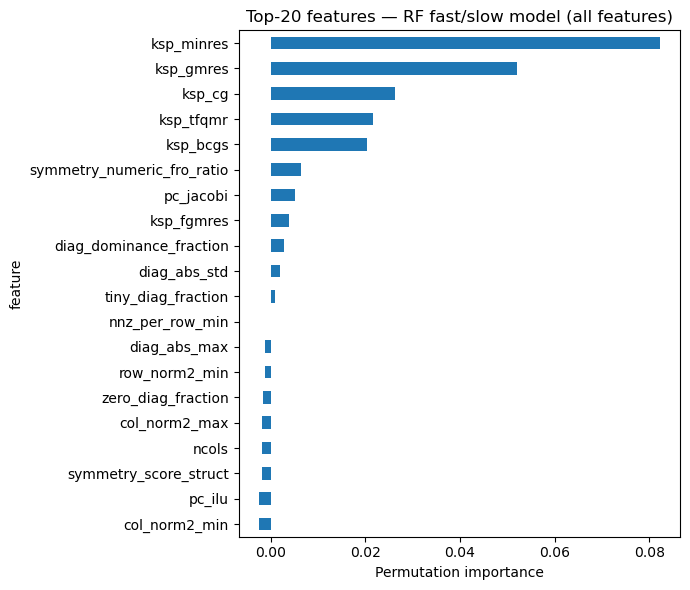

In [27]:
# Permutation importance — full feature set
perm = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)
imp_df = (pd.DataFrame({'feature': X_imp.columns,
                         'importance': perm.importances_mean})
            .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(7, 6))
imp_df.head(20).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Permutation importance')
ax.set_title('Top-20 features — RF fast/slow model (all features)')
plt.tight_layout()
plt.show()

## 2 · Boruta feature selection

Boruta compares each feature against randomly permuted shadow copies.
Only features that consistently outperform the best shadow feature are confirmed.

In [28]:
boruta_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=0, n_jobs=-1)

boruta = BorutaPy(
    estimator=boruta_rf,
    n_estimators='auto',
    perc=80,
    alpha=0.05,
    max_iter=150,
    random_state=0,
    verbose=1
)
boruta.fit(X_imp.values, y.values)

ranking = pd.DataFrame({
    'feature':   X_imp.columns,
    'selected':  boruta.support_,
    'tentative': boruta.support_weak_,
    'rank':      boruta.ranking_
}).sort_values(['rank', 'feature'])

selected_fast = ranking[ranking['selected']]['feature'].tolist()
tentative_fast = ranking[ranking['tentative']]['feature'].tolist()

if len(selected_fast) == 0:
    print('WARNING: Boruta selected 0 features — falling back to top-10 by rank.')
    selected_fast = ranking.head(10)['feature'].tolist()

print(f'\nSelected ({len(selected_fast)}): {selected_fast}')
print(f'Tentative: {tentative_fast}')
display(ranking.head(20))

Iteration: 1 / 150
Iteration: 2 / 150
Iteration: 3 / 150
Iteration: 4 / 150
Iteration: 5 / 150
Iteration: 6 / 150
Iteration: 7 / 150
Iteration: 8 / 150
Iteration: 9 / 150
Iteration: 10 / 150
Iteration: 11 / 150
Iteration: 12 / 150
Iteration: 13 / 150
Iteration: 14 / 150
Iteration: 15 / 150
Iteration: 16 / 150
Iteration: 17 / 150
Iteration: 18 / 150
Iteration: 19 / 150
Iteration: 20 / 150
Iteration: 21 / 150
Iteration: 22 / 150
Iteration: 23 / 150
Iteration: 24 / 150
Iteration: 25 / 150
Iteration: 26 / 150
Iteration: 27 / 150
Iteration: 28 / 150
Iteration: 29 / 150
Iteration: 30 / 150
Iteration: 31 / 150
Iteration: 32 / 150
Iteration: 33 / 150
Iteration: 34 / 150


BorutaPy finished running.

Iteration: 	35 / 150
Confirmed: 	1
Tentative: 	0
Rejected: 	38

Selected (1): ['diag_dominance_fraction']
Tentative: []


,feature,selected,tentative,rank
19,diag_dominance_fraction,True,False,1
4,ksp_minres,False,False,2
5,ksp_tfqmr,False,False,3
1,ksp_cg,False,False,4
13,nnz_per_row_std,False,False,5
38,pseudo_kappa,False,False,6
15,nnz_per_row_max,False,False,7
37,row_norm2_spread,False,False,8
12,nnz_per_row_mean,False,False,9
24,row_norm2_std,False,False,9


## 3 · Retrain RF on Boruta-selected features

=== RF — Boruta-selected features (fast/slow) ===
              precision    recall  f1-score   support

           0      0.719     0.722     0.721       209
           1      0.448     0.443     0.445       106

    accuracy                          0.629       315
   macro avg      0.583     0.583     0.583       315
weighted avg      0.628     0.629     0.628       315

Using 1 features: ['diag_dominance_fraction']


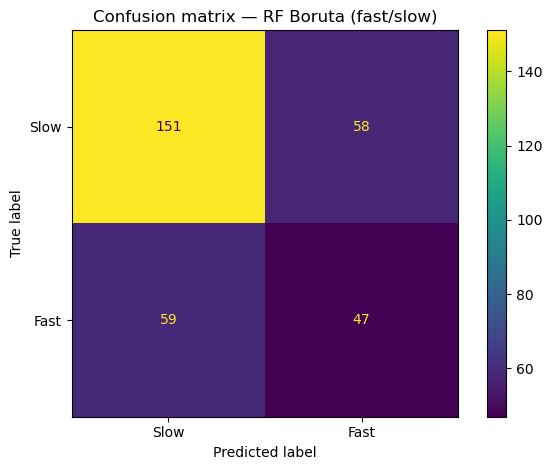

ksp     pc    
bcgs    ilu       185
        jacobi    210
cg      jacobi     82
fgmres  jacobi    123
gmres   ilu       154
        jacobi    158
minres  jacobi    151
tfqmr   jacobi    232
dtype: int64
Total rows: 1295
Unique matrices: 360


In [29]:
# Same train/test split indices, same imputed matrix
X_sel = X_imp[selected_fast]
X_sel_tr = X_sel.iloc[train_idx]
X_sel_te = X_sel.iloc[test_idx]

rf_boruta = RandomForestClassifier(
    n_estimators=500, random_state=0, class_weight='balanced', n_jobs=-1)
rf_boruta.fit(X_sel_tr, y_train)
pred_boruta = rf_boruta.predict(X_sel_te)

print('=== RF — Boruta-selected features (fast/slow) ===')
print(classification_report(y_test, pred_boruta, digits=3))
print(f'Using {len(selected_fast)} features: {selected_fast}')

ConfusionMatrixDisplay.from_predictions(y_test, pred_boruta,
    display_labels=['Slow', 'Fast'])
plt.title('Confusion matrix — RF Boruta (fast/slow)')
plt.tight_layout()
plt.show()
print(df.groupby(['ksp', 'pc']).size())
print('Total rows:', len(df))
print('Unique matrices:', df['matrix_id'].nunique())

## 4 · SHAP analysis

- **Beeswarm**: global view — which features matter most and in which direction
- **Bar**: mean absolute SHAP value per feature
- **Waterfall**: local explanation for a single slow prediction

In [34]:
# Train on full data with selected features for stable SHAP explanations
rf_shap = RandomForestClassifier(
    n_estimators=500, random_state=0, class_weight='balanced', n_jobs=-1)
rf_shap.fit(X_imp[selected_fast], y.values)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer(X_imp[selected_fast])

# Take class=1 (fast) for binary classification
sv = shap_values[..., 1] if shap_values.values.ndim == 3 else shap_values
print('SHAP values shape:', sv.values.shape)

SHAP values shape: (1295, 1)


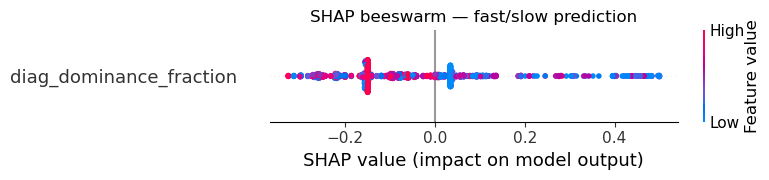

In [31]:
# Global beeswarm
plt.figure()
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title('SHAP beeswarm — fast/slow prediction')
plt.tight_layout()
plt.show()

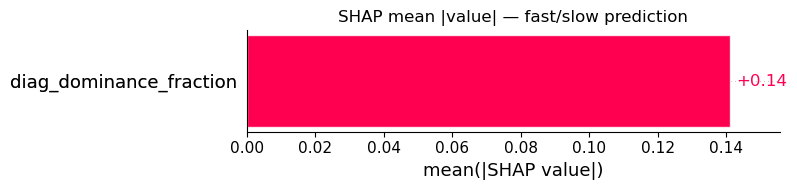

In [32]:
# Global bar
plt.figure()
shap.plots.bar(sv, max_display=15, show=False)
plt.title('SHAP mean |value| — fast/slow prediction')
plt.tight_layout()
plt.show()

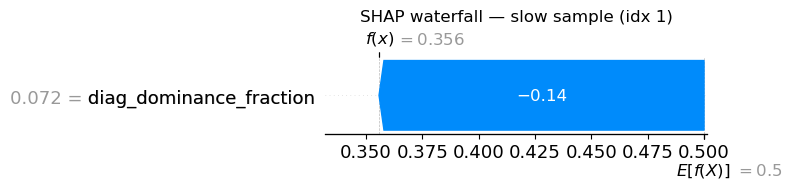

In [33]:
# Local waterfall — pick a slow sample and explain why it was predicted slow
slow_idx = np.where(y.values == 0)[0]
if len(slow_idx) > 0:
    sample_idx = slow_idx[0]
    plt.figure()
    shap.plots.waterfall(sv[sample_idx], max_display=12, show=False)
    plt.title(f'SHAP waterfall — slow sample (idx {sample_idx})')
    plt.tight_layout()
    plt.show()
else:
    print('No slow samples found.')